# ROGII - Wellbore Geology Prediction — EDA

Target: `TVT` for the blind ('evaluation zone') tail of each horizontal well.
Available signal: `GR` log (mostly known), known-zone `TVT_input`, trajectory `X/Y/Z/MD`, and a reference `typewell` (TVT vs GR vs Geology).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os

sns.set_theme(style='whitegrid')
DATA_DIR = 'data'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

well_ids = sorted({os.path.basename(f).split('__')[0] for f in glob.glob(os.path.join(TRAIN_DIR, '*__horizontal_well.csv'))})
print('n train wells:', len(well_ids))

def load_well(well_id, split='train'):
    d = TRAIN_DIR if split == 'train' else TEST_DIR
    hw = pd.read_csv(os.path.join(d, f'{well_id}__horizontal_well.csv'))
    tw = pd.read_csv(os.path.join(d, f'{well_id}__typewell.csv'))
    return hw, tw

n train wells: 773


## 1. Single well: shape of the problem

In [2]:
wid = well_ids[0]
hw, tw = load_well(wid)
known_mask = hw['TVT_input'].notna()
print(wid, 'rows:', len(hw), 'known:', known_mask.sum(), 'eval(blind):', (~known_mask).sum())
hw.describe()

000d7d20 rows: 5278 known: 1442 eval(blind): 3836


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,5278.000000,5.278000e+03,5.278000e+03,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,3020.000000,1442.000000
mean,14105.500000,2.983514e+06,1.071418e+06,-9673.194324,-9330.621821,-9504.671821,-9532.451821,-9605.801821,-9640.771821,-9781.161821,11715.831127,94.436961,11646.417864
std,1523.771691,2.997379e+01,1.503381e+03,80.961903,35.272977,35.272977,35.272977,35.272977,35.272977,35.272977,88.782092,18.627493,148.869554
min,11467.000000,2.983468e+06,1.069022e+06,-9755.610000,-9395.810000,-9569.860000,-9597.640000,-9670.990000,-9705.960000,-9846.350000,11236.020000,31.765827,11236.020000
25%,12786.250000,2.983487e+06,1.070090e+06,-9721.762500,-9362.307500,-9536.357500,-9564.137500,-9637.487500,-9672.457500,-9812.847500,11735.850000,85.068343,11566.195000
50%,14105.500000,2.983514e+06,1.071407e+06,-9689.230000,-9335.975000,-9510.025000,-9537.805000,-9611.155000,-9646.125000,-9786.515000,11742.130000,94.936506,11745.920000
75%,15424.750000,2.983535e+06,1.072723e+06,-9650.035000,-9296.665000,-9470.715000,-9498.495000,-9571.845000,-9606.815000,-9747.205000,11747.257500,103.960888,11747.465000
max,16744.000000,2.983578e+06,1.074041e+06,-9258.570000,-9271.000000,-9445.050000,-9472.830000,-9546.180000,-9581.150000,-9721.540000,11756.120000,217.352257,11756.120000


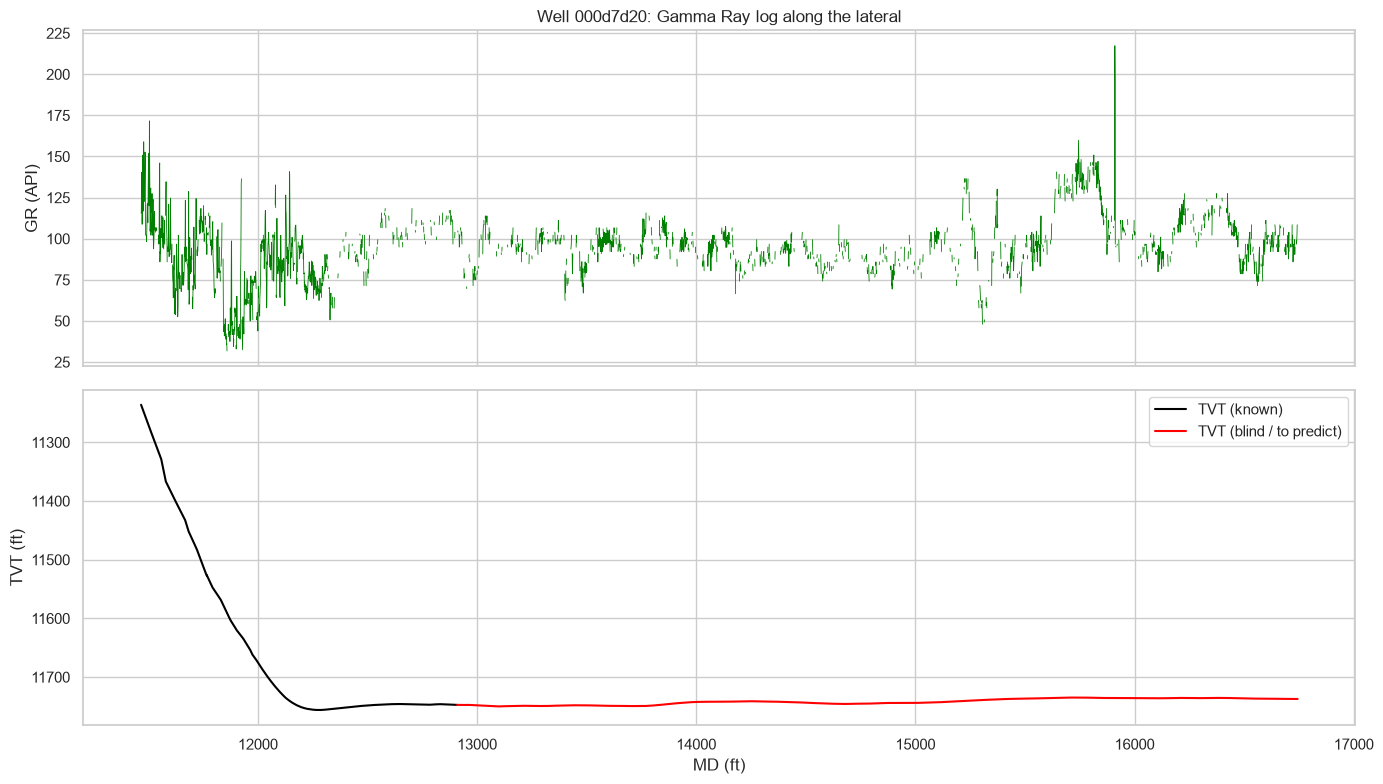

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(hw['MD'], hw['GR'], lw=0.6, color='green')
axes[0].set_ylabel('GR (API)')
axes[0].set_title(f'Well {wid}: Gamma Ray log along the lateral')

axes[1].plot(hw.loc[known_mask, 'MD'], hw.loc[known_mask, 'TVT'], color='black', label='TVT (known)')
axes[1].plot(hw.loc[~known_mask, 'MD'], hw.loc[~known_mask, 'TVT'], color='red', label='TVT (blind / to predict)')
axes[1].invert_yaxis()
axes[1].set_ylabel('TVT (ft)')
axes[1].set_xlabel('MD (ft)')
axes[1].legend()
plt.tight_layout()
plt.show()

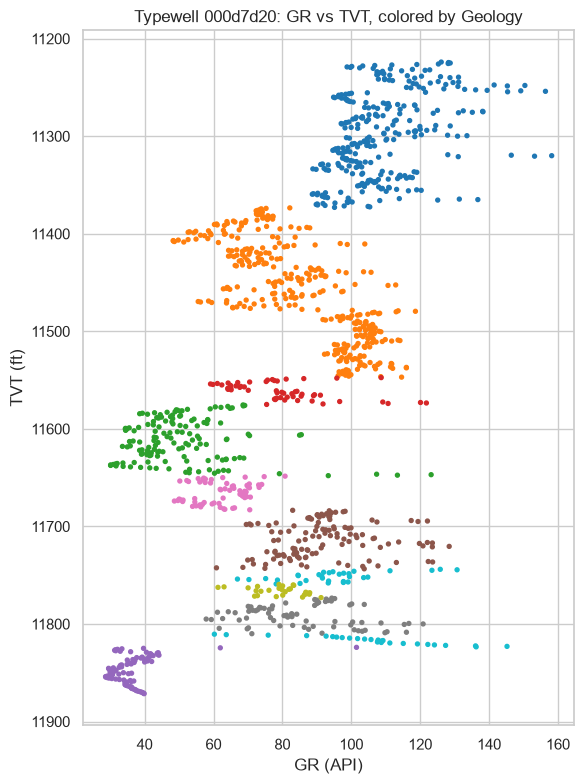

Geology
ANCC     348
ASTNL    146
EGFDL    121
BUDA      96
LBHL      74
EGFDU     70
ASTNU     56
LTHL      31
LTGT      28
MNSS      27
Name: count, dtype: int64

In [4]:
fig, ax = plt.subplots(figsize=(6, 8))
sc = ax.scatter(tw['GR'], tw['TVT'], c=tw['Geology'].astype('category').cat.codes, cmap='tab10', s=8)
ax.invert_yaxis()
ax.set_xlabel('GR (API)')
ax.set_ylabel('TVT (ft)')
ax.set_title(f'Typewell {wid}: GR vs TVT, colored by Geology')
plt.tight_layout()
plt.show()
tw['Geology'].value_counts()

## 2. Across all wells: distributions

In [5]:
rows = []
for wid in well_ids:
    hw, tw = load_well(wid)
    known_mask = hw['TVT_input'].notna()
    rows.append({
        'well_id': wid,
        'n_rows': len(hw),
        'n_known': known_mask.sum(),
        'n_eval': (~known_mask).sum(),
        'frac_eval': (~known_mask).mean(),
        'tvt_min': hw['TVT'].min(),
        'tvt_max': hw['TVT'].max(),
        'tvt_range': hw['TVT'].max() - hw['TVT'].min(),
        'gr_missing_frac': hw['GR'].isna().mean(),
        'n_typewell_pts': len(tw),
    })
summary = pd.DataFrame(rows)
summary.describe()

,n_rows,n_known,n_eval,frac_eval,tvt_min,tvt_max,tvt_range,gr_missing_frac,n_typewell_pts
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,6587.652005,1692.452781,4895.199224,0.733161,10834.348900,11568.817827,734.468926,0.293854,2027.225097
std,1311.463547,217.343826,1301.178409,0.063776,635.417774,620.040737,175.484377,0.190857,1009.473248
min,2058.000000,851.000000,407.000000,0.197765,9245.190000,10072.180000,158.930000,0.006527,636.000000
25%,5706.000000,1546.000000,4044.000000,0.700344,10353.060000,11052.450000,588.570000,0.121198,1498.000000
50%,6576.000000,1703.000000,4840.000000,0.739991,10650.900000,11384.630000,758.220000,0.277038,1874.000000
75%,7388.000000,1839.000000,5694.000000,0.775462,11358.270000,12067.510000,856.510000,0.463952,2158.000000
max,12141.000000,2392.000000,10052.000000,0.875165,12444.080000,12893.890000,1256.700000,0.800989,10043.000000


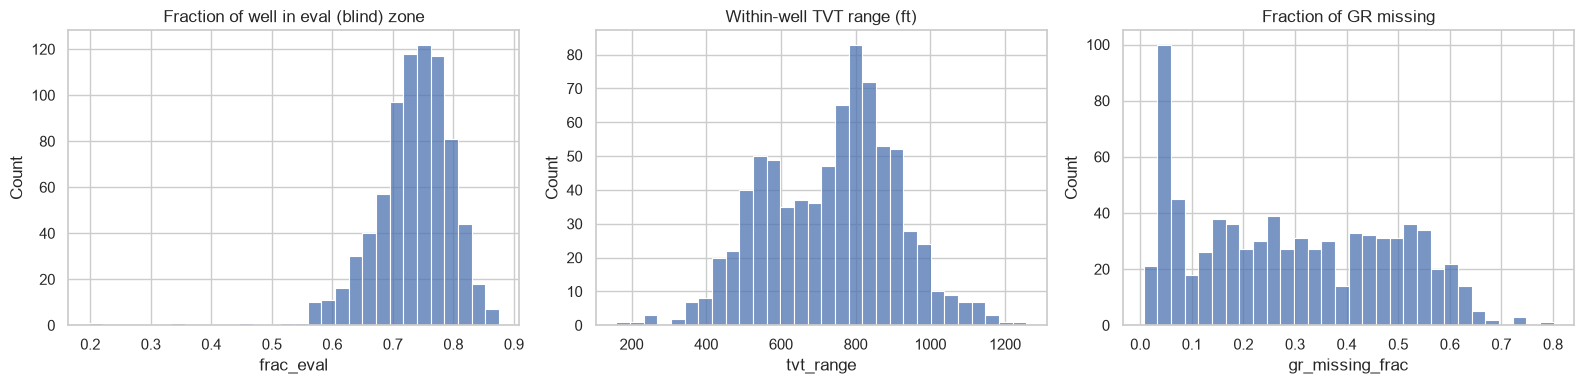

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(summary['frac_eval'], bins=30, ax=axes[0])
axes[0].set_title('Fraction of well in eval (blind) zone')
sns.histplot(summary['tvt_range'], bins=30, ax=axes[1])
axes[1].set_title('Within-well TVT range (ft)')
sns.histplot(summary['gr_missing_frac'], bins=30, ax=axes[2])
axes[2].set_title('Fraction of GR missing')
plt.tight_layout()
plt.show()

## 3. Naive baselines (sanity check on train, using known-zone as a pseudo-test)

We hide the true tail of each well's *known* zone and see what trivial extrapolation scores, to calibrate what a 'good' RMSE looks like before modeling.

In [7]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# pseudo-validation: for each well, pretend the last X% of the *known* zone is blind
results_flat = []
results_trend = []
for wid in well_ids[:150]:
    hw, _ = load_well(wid)
    known = hw[hw['TVT_input'].notna()].reset_index(drop=True)
    if len(known) < 50:
        continue
    split = int(len(known) * 0.8)
    train_part, holdout = known.iloc[:split], known.iloc[split:]
    last_val = train_part['TVT'].iloc[-1]
    results_flat.append(rmse(holdout['TVT'], np.full(len(holdout), last_val)))

    # linear trend extrapolation from last N points
    n_fit = min(200, len(train_part))
    coeffs = np.polyfit(train_part['MD'].iloc[-n_fit:], train_part['TVT'].iloc[-n_fit:], 1)
    pred_trend = np.polyval(coeffs, holdout['MD'])
    results_trend.append(rmse(holdout['TVT'], pred_trend))

print('Flat (last known value) baseline RMSE: mean=%.2f median=%.2f' % (np.mean(results_flat), np.median(results_flat)))
print('Local linear-trend baseline RMSE: mean=%.2f median=%.2f' % (np.mean(results_trend), np.median(results_trend)))
print()
print('For reference, real public leaderboard: top score ~5.3, median ~9.9 (RMSE in ft)')

Flat (last known value) baseline RMSE: mean=3.72 median=2.60
Local linear-trend baseline RMSE: mean=5.97 median=3.14

For reference, real public leaderboard: top score ~5.3, median ~9.9 (RMSE in ft)
